## **Klasifikasi Emosi dari Teks Menggunakan Neural Network**

### **Imports**

In [1]:
import os
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from loguru import logger
import matplotlib.pyplot as plt
import pickle
from nn.model import NeuralNetworkTwoHidden
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, mutual_info_classif

### **Configuration**

In [2]:

# -------------------- CONFIGURATIONS --------------------
experiments = [
    {"hidden": 24, "lr": 0.001,  "name": "fs_h24_lr1e-3"},
    {"hidden": 128, "lr": 0.001,  "name": "fs_h128_lr1e-3"},
    {"hidden": 24, "lr": 0.0001, "name": "fs_h24_lr1e-4"},
    {"hidden": 128, "lr": 0.0001, "name": "fs_h128_lr1e-4"},
]

model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

# -------------------- LOAD & PREPROCESS DATA --------------------
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

df = pd.read_csv("dataset/combined_emotion.csv")
df.dropna(inplace=True)
df['sentence'] = df['sentence'].str.lower()

def clean_text(text):
    return ' '.join([w for w in text.split() if w not in stop_words])

df['sentence'] = df['sentence'].apply(clean_text)

# -------------------- LIMIT TO 100K SAMPLES --------------------
# Ambil secara proporsional agar distribusi label tetap seimbang
# sample_size = 400_000
# df = df.groupby('emotion', group_keys=False).apply(
#     lambda x: x.sample(frac=1, random_state=42)  # shuffle tiap kelas
# ).groupby('emotion', group_keys=False).head(int(sample_size / df['emotion'].nunique()))
# df = df.sample(n=sample_site)

print(f"Dataset truncated to {len(df)} samples")

# -------------------- PREPARE X AND y --------------------
X = df['sentence'].tolist()
y = df['emotion'].tolist()

print("Data per label (setelah dibatasi):")
print(df['emotion'].value_counts())

[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


Dataset truncated to 422746 samples
Data per label (setelah dibatasi):
emotion
joy        143067
sad        121187
anger       59317
fear        49649
love        34554
suprise     14972
Name: count, dtype: int64


### **Train Word2Vec**

In [3]:

# -------------------- SPLIT DATA --------------------
X_train_text, X_val_text, y_train_raw, y_val_raw = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Label encoding
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_val = le.transform(y_val_raw)
n_classes = len(le.classes_)

# -------------------- WORD2VEC ONLY ON TRAIN DATA --------------------
tokenized_train = [s.split() for s in X_train_text]
w2v = Word2Vec(sentences=tokenized_train, vector_size=150, window=5, min_count=1, workers=4, epochs=10)
wv = w2v.wv

def sent2vec(s):
    words = s.split()
    vecs = [wv[w] for w in words if w in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(150)

# Vectorize
X_train_vec = np.vstack([sent2vec(s) for s in X_train_text])
X_val_vec = np.vstack([sent2vec(s) for s in X_val_text])

# -------------------- FEATURE SELECTION (k = 135) --------------------
selector = SelectKBest(score_func=f_classif, k=135)
X_train_fs = selector.fit_transform(X_train_vec, y_train)  # fit only on training
X_val_fs = selector.transform(X_val_vec)                   # apply same transform to validation

# -------------------- STANDARDIZE --------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fs).T
X_val_scaled = scaler.transform(X_val_fs).T

# -------------------- ONE HOT ENCODE --------------------
def one_hot(labels, num_classes):
    arr = np.zeros((len(labels), num_classes))
    for i, l in enumerate(labels):
        arr[i, l] = 1
    return arr.T

Y_train = one_hot(y_train, n_classes)
Y_val   = one_hot(y_val, n_classes)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


### **Build & Train Model**


🚀 Training fs_h128_lr1e-3
Hidden=128, LR=0.001

Epoch 1/100000 | Train Loss: 0.2253 | Train Acc: 0.4974 | Val Loss: 0.1929 | Val Acc: 0.5803
Epoch 2/100000 | Train Loss: 0.1796 | Train Acc: 0.6078 | Val Loss: 0.1704 | Val Acc: 0.6270
Epoch 3/100000 | Train Loss: 0.1641 | Train Acc: 0.6383 | Val Loss: 0.1596 | Val Acc: 0.6468
Epoch 4/100000 | Train Loss: 0.1554 | Train Acc: 0.6553 | Val Loss: 0.1527 | Val Acc: 0.6589
Epoch 5/100000 | Train Loss: 0.1494 | Train Acc: 0.6672 | Val Loss: 0.1477 | Val Acc: 0.6684
Epoch 6/100000 | Train Loss: 0.1449 | Train Acc: 0.6762 | Val Loss: 0.1439 | Val Acc: 0.6762
Epoch 7/100000 | Train Loss: 0.1414 | Train Acc: 0.6830 | Val Loss: 0.1409 | Val Acc: 0.6824
Epoch 8/100000 | Train Loss: 0.1385 | Train Acc: 0.6888 | Val Loss: 0.1384 | Val Acc: 0.6880
Epoch 9/100000 | Train Loss: 0.1361 | Train Acc: 0.6934 | Val Loss: 0.1363 | Val Acc: 0.6916
Epoch 10/100000 | Train Loss: 0.1340 | Train Acc: 0.6974 | Val Loss: 0.1344 | Val Acc: 0.6954
Epoch 11/100000 | Tr

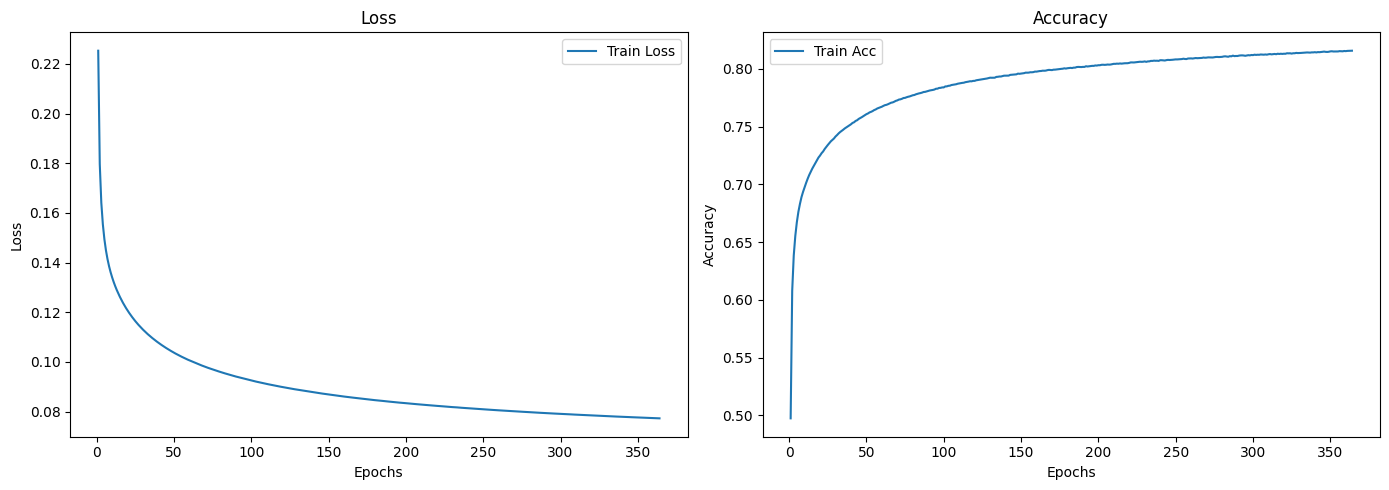

✅ Accuracy (fs_h128_lr1e-3): 0.7876
              precision    recall  f1-score   support

       anger       0.75      0.74      0.75     11863
        fear       0.74      0.71      0.72      9930
         joy       0.83      0.87      0.85     28614
        love       0.70      0.63      0.66      6911
         sad       0.80      0.83      0.81     24238
     suprise       0.67      0.54      0.60      2994

    accuracy                           0.79     84550
   macro avg       0.75      0.72      0.73     84550
weighted avg       0.78      0.79      0.79     84550



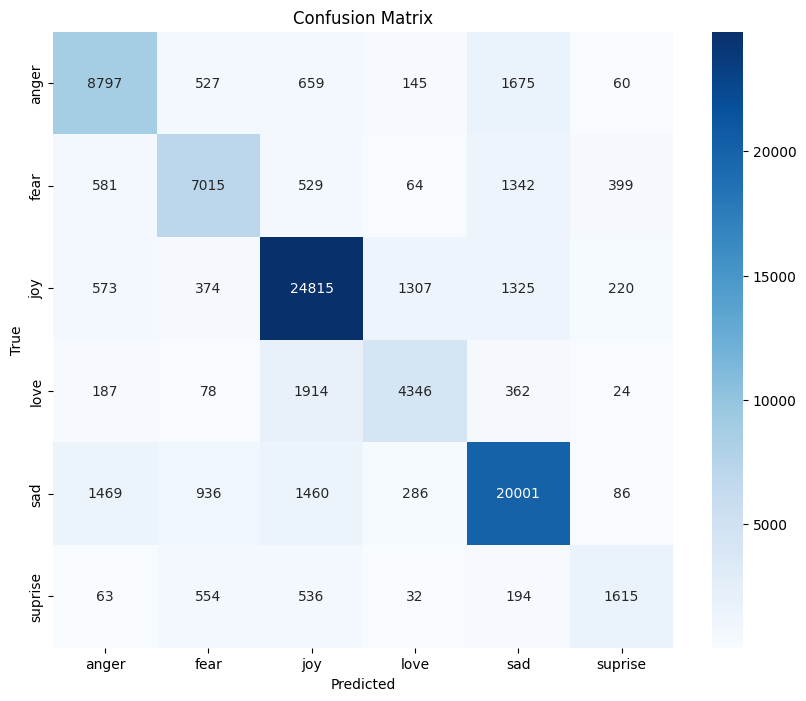

💾 Model saved as: models/fs_h128_lr1e-3.pkl

🎯 Training selesai untuk semua SMOTE!


In [4]:

# -------------------- FS 2 --------------------

print(f"\n==============================")
print(f"🚀 Training {experiments[1]['name']}")
print(f"Hidden={experiments[1]['hidden']}, LR={experiments[1]['lr']}")
print(f"==============================\n")

model = NeuralNetworkTwoHidden(
    input_dim=100,
    hidden1=experiments[1]['hidden'],
    hidden2=experiments[1]['hidden'] // 2,
    output_dim=6,
    learning_rate=experiments[1]['lr'],
    patience=20,
    batch_size=64,
)

model.train(
    X_train_scaled,
    Y_train,
    epochs=100000,
    verbose=True,
    plot=True,
    X_val=X_val_scaled, Y_val=Y_val,
)
y_pred = model.predict(X_val_scaled)
y_true = np.argmax(Y_val, axis=0)

acc = accuracy_score(y_true, y_pred)
print(f"✅ Accuracy ({experiments[1]['name']}): {acc:.4f}")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion Matrix
model.confusion_matrix(y_true, y_pred, le)


# Save model
file = os.path.join(model_dir, f"{experiments[1]['name']}.pkl")
with open(file, "wb") as f:
    pickle.dump({"model": model, "label_encoder": le}, f)

print(f"💾 Model saved as: {file}")
print("\n🎯 Training selesai untuk semua SMOTE!")



🚀 Training fs_h128_lr1e-3
Hidden=128, LR=0.001

Epoch 1/100000 | Train Loss: 0.2290 | Train Acc: 0.4846 | Val Loss: 0.1950 | Val Acc: 0.5756
Epoch 2/100000 | Train Loss: 0.1780 | Train Acc: 0.6135 | Val Loss: 0.1657 | Val Acc: 0.6378
Epoch 3/100000 | Train Loss: 0.1575 | Train Acc: 0.6541 | Val Loss: 0.1517 | Val Acc: 0.6670
Epoch 4/100000 | Train Loss: 0.1465 | Train Acc: 0.6756 | Val Loss: 0.1434 | Val Acc: 0.6834
Epoch 5/100000 | Train Loss: 0.1394 | Train Acc: 0.6898 | Val Loss: 0.1377 | Val Acc: 0.6949
Epoch 6/100000 | Train Loss: 0.1343 | Train Acc: 0.7004 | Val Loss: 0.1334 | Val Acc: 0.7031
Epoch 7/100000 | Train Loss: 0.1304 | Train Acc: 0.7085 | Val Loss: 0.1300 | Val Acc: 0.7105
Epoch 8/100000 | Train Loss: 0.1272 | Train Acc: 0.7152 | Val Loss: 0.1272 | Val Acc: 0.7162
Epoch 9/100000 | Train Loss: 0.1245 | Train Acc: 0.7203 | Val Loss: 0.1248 | Val Acc: 0.7211
Epoch 10/100000 | Train Loss: 0.1221 | Train Acc: 0.7252 | Val Loss: 0.1227 | Val Acc: 0.7258
Epoch 11/100000 | Tr

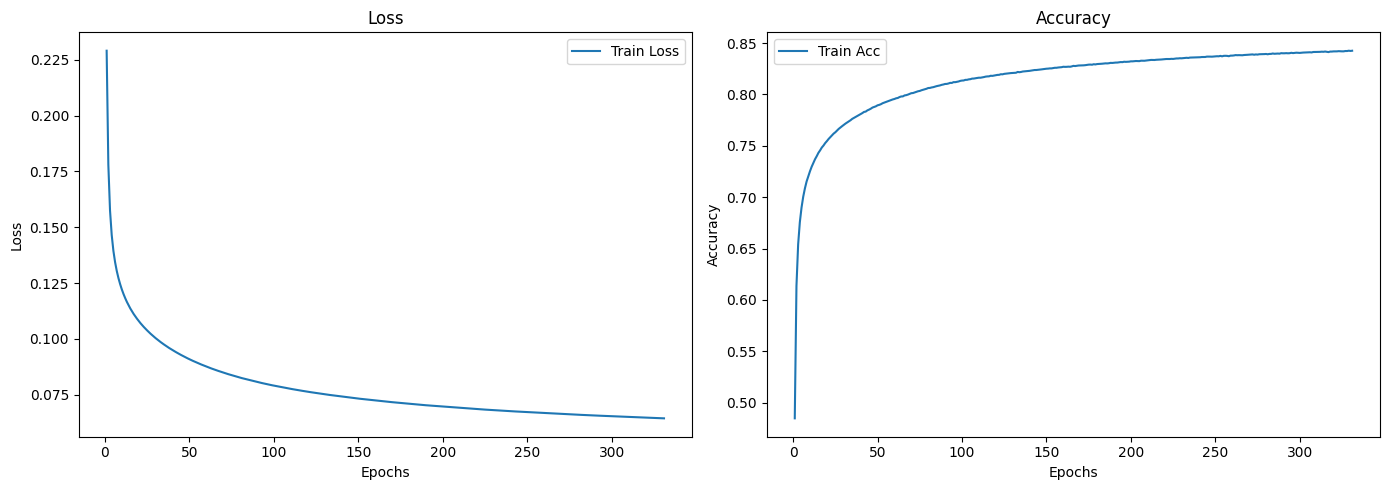

✅ Accuracy (fs_h128_lr1e-3): 0.8112
              precision    recall  f1-score   support

       anger       0.79      0.78      0.79     11863
        fear       0.76      0.73      0.74      9930
         joy       0.85      0.88      0.86     28614
        love       0.72      0.66      0.69      6911
         sad       0.83      0.85      0.84     24238
     suprise       0.68      0.61      0.64      2994

    accuracy                           0.81     84550
   macro avg       0.77      0.75      0.76     84550
weighted avg       0.81      0.81      0.81     84550



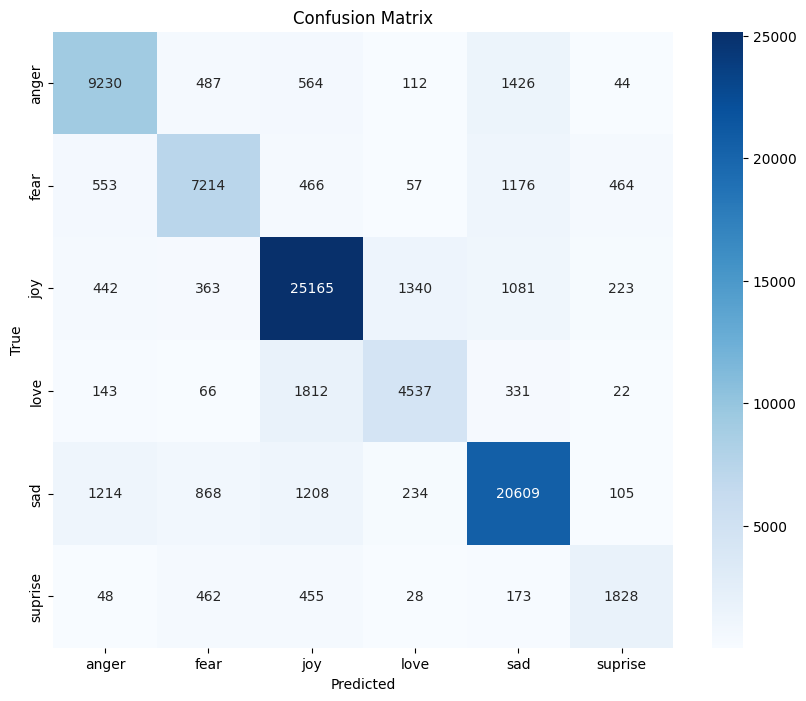

💾 Model saved as: models/fs_h128_lr1e-3.pkl

🎯 Training selesai untuk semua SMOTE!


In [4]:

# -------------------- FS 2 --------------------

print(f"\n==============================")
print(f"🚀 Training {experiments[1]['name']}")
print(f"Hidden={experiments[1]['hidden']}, LR={experiments[1]['lr']}")
print(f"==============================\n")

model = NeuralNetworkTwoHidden(
    input_dim=135,
    hidden1=experiments[1]['hidden'],
    hidden2=experiments[1]['hidden'] // 2,
    output_dim=6,
    learning_rate=experiments[1]['lr'],
    patience=20,
    batch_size=64,
)

model.train(
    X_train_scaled,
    Y_train,
    epochs=100000,
    verbose=True,
    plot=True,
    X_val=X_val_scaled, Y_val=Y_val,
)
y_pred = model.predict(X_val_scaled)
y_true = np.argmax(Y_val, axis=0)

acc = accuracy_score(y_true, y_pred)
print(f"✅ Accuracy ({experiments[1]['name']}): {acc:.4f}")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion Matrix
model.confusion_matrix(y_true, y_pred, le)


# Save model
file = os.path.join(model_dir, f"{experiments[1]['name']}.pkl")
with open(file, "wb") as f:
    pickle.dump({"model": model, "label_encoder": le}, f)

print(f"💾 Model saved as: {file}")
print("\n🎯 Training selesai untuk semua SMOTE!")
